# Streaming with Langchain

In [1]:
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END

## Reducers
from typing import Annotated
from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    messages:Annotated[list,add_messages]

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")


In [4]:
# from langchain_openai import ChatOpenAI
# llm=ChatOpenAI(model="gpt-4o")
# llm.invoke("Hello")

In [6]:
# from langchain_groq import ChatGroq

# llm_groq=ChatGroq(model="qwen-qwq-32b")
from langchain_ollama import ChatOllama
llm_ollama=ChatOllama(model="llama3.2:latest")
llm_ollama.invoke("Hey I am Krish and i like to play cricket")

AIMessage(content="Nice to meet you, Krish! Cricket is an excellent sport, isn't it? What's your favorite aspect of the game - batting, bowling, or fielding? Do you have a favorite team or player that inspires you?", additional_kwargs={}, response_metadata={'model': 'llama3.2:latest', 'created_at': '2026-04-29T21:42:33.5430187Z', 'done': True, 'done_reason': 'stop', 'total_duration': 6935665500, 'load_duration': 6359209900, 'prompt_eval_count': 35, 'prompt_eval_duration': 19042200, 'eval_count': 47, 'eval_duration': 492850700, 'model_name': 'llama3.2:latest'}, id='lc_run--019ddb31-7bf4-73c3-99a3-ecd6db9e9974-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 35, 'output_tokens': 47, 'total_tokens': 82})

### We Will start With Creating Nodes

In [7]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()
def superbot(state:State):
    return {"messages":[llm_ollama.invoke(state['messages'])]}

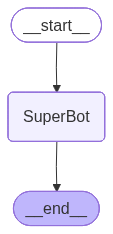

In [8]:
graph=StateGraph(State)

## node
graph.add_node("SuperBot",superbot)
## Edges

graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)


graph_builder=graph.compile(checkpointer=memory)


## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [9]:
## Invocation

config = {"configurable": {"thread_id": "1"}}

graph_builder.invoke({'messages':"Hi,My name is Krish And I like cricket"},config)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='fe0da1f9-32ff-4cf3-a11c-4e397b7a2e91'),
  AIMessage(content="Namaste Krish! It's great to meet you! Cricket is an amazing sport, isn't it? Which team do you support - India, your favorite country or perhaps one of the other top teams in the world?\n\nAre you a fan of any particular cricketer or have a favorite player who inspires you? Do you follow international matches, T20 leagues like IPL or Big Bash, or do you prefer watching cricket on TV?", additional_kwargs={}, response_metadata={'model': 'llama3.2:latest', 'created_at': '2026-04-29T21:42:38.032941Z', 'done': True, 'done_reason': 'stop', 'total_duration': 1548046000, 'load_duration': 333974700, 'prompt_eval_count': 35, 'prompt_eval_duration': 117355100, 'eval_count': 88, 'eval_duration': 1010913800, 'model_name': 'llama3.2:latest'}, id='lc_run--019ddb31-a2c3-78c2-b45e-dcb2fc98ee8d-0', tool_calls=[], invali

### Streaming 
Methods: .stream() and astream()

- These methods are sync and async methods for streaming back results.

Additional parameters in streaming modes for graph state

- **values** : This streams the full state of the graph after each node is called.
- **updates** : This streams updates to the state of the graph after each node is called.

![image.png](attachment:image.png)

In [10]:
config={"configurable":{"thread_id":"2"}}
for chunk in graph_builder.stream({'messages':"Hi, my name is Krish And I like Cricket"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="Namaste Krish! It's great to meet you. A cricket fan, eh? Which part of the world are you from? Do you follow any specific teams or players? India has a rich cricket history, by the way!\n\n(Also, feel free to ask me any cricket-related questions or discuss your favorite teams and players)", additional_kwargs={}, response_metadata={'model': 'llama3.2:latest', 'created_at': '2026-04-29T21:43:24.0168617Z', 'done': True, 'done_reason': 'stop', 'total_duration': 1340090900, 'load_duration': 291056900, 'prompt_eval_count': 35, 'prompt_eval_duration': 258805700, 'eval_count': 67, 'eval_duration': 723838300, 'model_name': 'llama3.2:latest'}, id='lc_run--019ddb32-5731-7203-8b9e-57dc5d70e4ae-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 35, 'output_tokens': 67, 'total_tokens': 102})]}}


In [11]:
config={"configurable":{"thread_id":"2"}}
for chunk in graph_builder.stream({'messages':" I also like to play football"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="A sports enthusiast! Football (or soccer) is an amazing sport that requires skill, strategy, and teamwork. Do you have a favorite football team or player? Are you part of a local team or just enjoy playing with friends?\n\nBy the way, since you mentioned cricket earlier, I'm curious - do you play both cricket and football regularly, or is one more prominent in your life?\n\n(Also, if you want to talk about tactics, formations, or strategies for either sport, feel free to share!)", additional_kwargs={}, response_metadata={'model': 'llama3.2:latest', 'created_at': '2026-04-29T21:43:50.0558711Z', 'done': True, 'done_reason': 'stop', 'total_duration': 1773253500, 'load_duration': 298449400, 'prompt_eval_count': 117, 'prompt_eval_duration': 263925300, 'eval_count': 103, 'eval_duration': 1098613700, 'model_name': 'llama3.2:latest'}, id='lc_run--019ddb32-bb36-7563-bc8e-f7d0baea45c7-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_t

In [12]:
config={"configurable":{"thread_id":"2"}}
for chunk in graph_builder.stream({'messages':"I also like football"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi, my name is Krish And I like Cricket', additional_kwargs={}, response_metadata={}, id='a591f9b3-ca16-4553-8d69-e94d00be5090'), AIMessage(content="Namaste Krish! It's great to meet you. A cricket fan, eh? Which part of the world are you from? Do you follow any specific teams or players? India has a rich cricket history, by the way!\n\n(Also, feel free to ask me any cricket-related questions or discuss your favorite teams and players)", additional_kwargs={}, response_metadata={'model': 'llama3.2:latest', 'created_at': '2026-04-29T21:43:24.0168617Z', 'done': True, 'done_reason': 'stop', 'total_duration': 1340090900, 'load_duration': 291056900, 'prompt_eval_count': 35, 'prompt_eval_duration': 258805700, 'eval_count': 67, 'eval_duration': 723838300, 'model_name': 'llama3.2:latest'}, id='lc_run--019ddb32-5731-7203-8b9e-57dc5d70e4ae-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 35, 'output_tokens': 67, 'total_tokens': 102}), H

#### Streaming The Responses With astream Method

**Streaming tokens**
We often want to stream more than graph state.

In particular, with chat model calls it is common to stream the **tokens** as they are generated.

We can do this using the .astream_events method, which streams back events as they happen inside nodes!

Each event is a dict with a few keys:

- event: This is the type of event that is being emitted.
- name: This is the name of event.
- data: This is the data associated with the event.
- metadata: Containslanggraph_node, the node emitting the event.

In [14]:
config={"configurable":{"thread_id":"3"}}
async for event in graph_builder.astream_events({"messages":["hi my name is Krish and I like to play cricket"]},config=config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['hi my name is Krish and I like to play cricket']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019ddb35-4701-7172-80b3-bb74d06bff1d', 'metadata': {'thread_id': '3'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='hi my name is Krish and I like to play cricket', additional_kwargs={}, response_metadata={}, id='cb769684-a1e2-487d-b9d5-31f84d396396'), AIMessage(content="Hi Krish! Nice to meet you. Cricket is a fantastic sport, isn't it? What's your favorite aspect of playing cricket - batting, bowling, or fielding? And are you part of any local cricket teams or do you just play for fun with friends?", additional_kwargs={}, response_metadata={'model': 'llama3.2:latest', 'created_at': '2026-04-29T21:45:58.0680341Z', 'done': True, 'done_reason': 'stop', 'total_duration': 1465153900, 'load_duration': 474301300, 'prompt_eval_count': 36, 'prompt_eval_duration': 281399600, 'eval_coun